# ADNI NIfTI Preprocessed Dataset — Exploratory Data Analysis

**Dataset**: Alzheimer's Disease Neuroimaging Initiative (ADNI)  
**Task**: 3-class classification — **AD** (Alzheimer's Disease) · **MCI** (Mild Cognitive Impairment) · **CN** (Cognitively Normal)  
**Format**: Preprocessed axial brain slices (PNG, 224×224, RGB)

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Inventory](#2)
3. [Preprocessing Log Analysis](#3)
4. [Class Distribution](#4)
5. [Slice-Count Distribution](#5)
6. [Image Properties & Sanity Checks](#6)
7. [Sample Visualisation per Class](#7)
8. [Pixel Intensity Analysis](#8)
9. [Per-Class Intensity Distributions](#9)
10. [Spatial Mean / Std Maps](#10)
11. [Edge & Texture Analysis](#11)
12. [Image Similarity (SSIM Intra-class)](#12)
13. [Duplicate / Near-Duplicate Detection](#13)
14. [Data-Quality Summary & Recommendations](#14)

<a id='1'></a>
## 1 · Setup & Imports

In [4]:
import os, glob, json, warnings, collections, hashlib, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from scipy import ndimage
from skimage.metrics import structural_similarity as ssim
from skimage import filters

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
})

# Auto-detect Kaggle vs Local environment
if os.path.exists("/kaggle/input"):
    print(" Kaggle environment detected!")
    # Find the folder containing the AD directory
    ad_dirs = glob.glob("/kaggle/input/**/AD", recursive=True)
    DATA_ROOT = os.path.dirname(ad_dirs[0]) if ad_dirs else "/kaggle/input"
else:
    print(" Local environment detected!")
    DATA_ROOT = "."

print(f" Data Root: {DATA_ROOT}")

CLASSES   = ["AD", "MCI", "CN"]
CLASS_COLORS = {"AD": "#e74c3c", "MCI": "#f39c12", "CN": "#2ecc71"}
print(" Setup OK")

🌍 Kaggle environment detected!
📁 Data Root: /kaggle/input/datasets/idresooo/dataset/adni_nifti_preprocessed
✅  Setup OK


<a id='2'></a>
## 2 · Dataset Inventory

In [5]:
rows = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    for subj in sorted(os.listdir(cls_dir)):
        subj_dir = os.path.join(cls_dir, subj)
        if not os.path.isdir(subj_dir):
            continue
        pngs = sorted(glob.glob(os.path.join(subj_dir, "*.png")))
        sizes = [os.path.getsize(p) for p in pngs]
        rows.append({
            "subject": subj,
            "label": cls,
            "n_slices": len(pngs),
            "total_bytes": sum(sizes),
            "mean_file_kb": np.mean(sizes)/1024 if sizes else 0,
        })

df = pd.DataFrame(rows)
print(f"Subjects : {len(df)}")
print(f"Classes  : {df['label'].nunique()}")
print(f"Slices   : {df['n_slices'].sum():,}")
print(f"Disk     : {df['total_bytes'].sum()/1e6:.1f} MB")
df.head()

Subjects : 320
Classes  : 3
Slices   : 8,512
Disk     : 394.3 MB


,subject,label,n_slices,total_bytes,mean_file_kb
0,005_S_0814,AD,25,948416,37.047500
1,011_S_6303,AD,27,1263246,45.690321
2,013_S_0996,AD,27,1395118,50.459997
3,016_S_6839,AD,25,1023694,39.988047
4,022_S_6796,AD,27,1327645,48.019567


<a id='3'></a>
## 3 · Preprocessing Log Analysis

In [6]:
with open(os.path.join(DATA_ROOT, "preprocessing_stats.json")) as f:
    stats = json.load(f)

stats_df = pd.DataFrame(stats)
print(f"Log entries        : {len(stats_df)}")
print(f"Subjects on disk   : {len(df)}")
print(f"Entries with errors : {stats_df['error'].notna().sum() if 'error' in stats_df.columns else 0}")
if "error" in stats_df.columns:
    err = stats_df[stats_df["error"].notna()]
    if len(err):
        display(err[["subject","label","slices_saved","error"]])

# Original volume shapes
if "original_shape" in stats_df.columns:
    shapes = stats_df.dropna(subset=["original_shape"])
    shape_strs = shapes["original_shape"].apply(lambda x: str(tuple(x)) if isinstance(x, list) else str(x))
    print("\nOriginal NIfTI shapes encountered:")
    print(shape_strs.value_counts().to_string())

Log entries        : 389
Subjects on disk   : 320
Entries with errors : 1


,subject,label,slices_saved,error
16,005_S_0572,MCI,0,image must have 3 dimensions



Original NIfTI shapes encountered:
original_shape
(208, 240, 256)    41
(160, 240, 256)    34
(176, 240, 256)    34
(196, 256, 256)    29
(211, 256, 256)    11
(166, 256, 256)     9
(160, 256, 256)     2
(199, 256, 256)     1


<a id='4'></a>
## 4 · Class Distribution

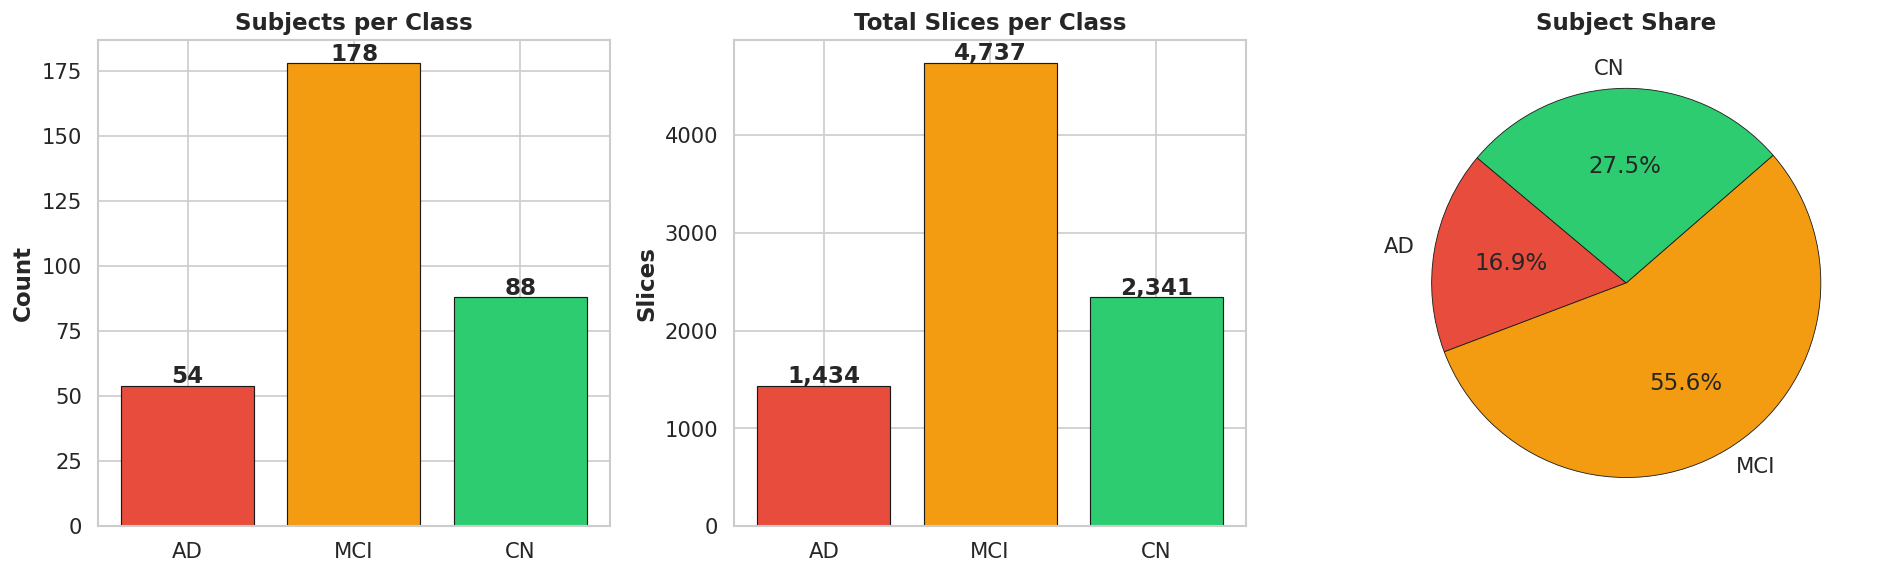


Imbalance ratio (majority / minority): 3.30:1


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4a — subject counts
counts = df["label"].value_counts().reindex(CLASSES)
colors = [CLASS_COLORS[c] for c in CLASSES]
axes[0].bar(CLASSES, counts, color=colors, edgecolor="k", linewidth=0.7)
for i, v in enumerate(counts):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")
axes[0].set_title("Subjects per Class")
axes[0].set_ylabel("Count")

# 4b — slice counts
slice_counts = df.groupby("label")["n_slices"].sum().reindex(CLASSES)
axes[1].bar(CLASSES, slice_counts, color=colors, edgecolor="k", linewidth=0.7)
for i, v in enumerate(slice_counts):
    axes[1].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")
axes[1].set_title("Total Slices per Class")
axes[1].set_ylabel("Slices")

# 4c — pie
axes[2].pie(counts, labels=CLASSES, colors=colors, autopct="%1.1f%%",
            startangle=140, wedgeprops={"edgecolor":"k","linewidth":0.5})
axes[2].set_title("Subject Share")

plt.tight_layout()
plt.show()

# Imbalance ratio
majority = counts.max()
minority = counts.min()
print(f"\nImbalance ratio (majority / minority): {majority/minority:.2f}:1")

<a id='5'></a>
## 5 · Slice-Count Distribution per Subject

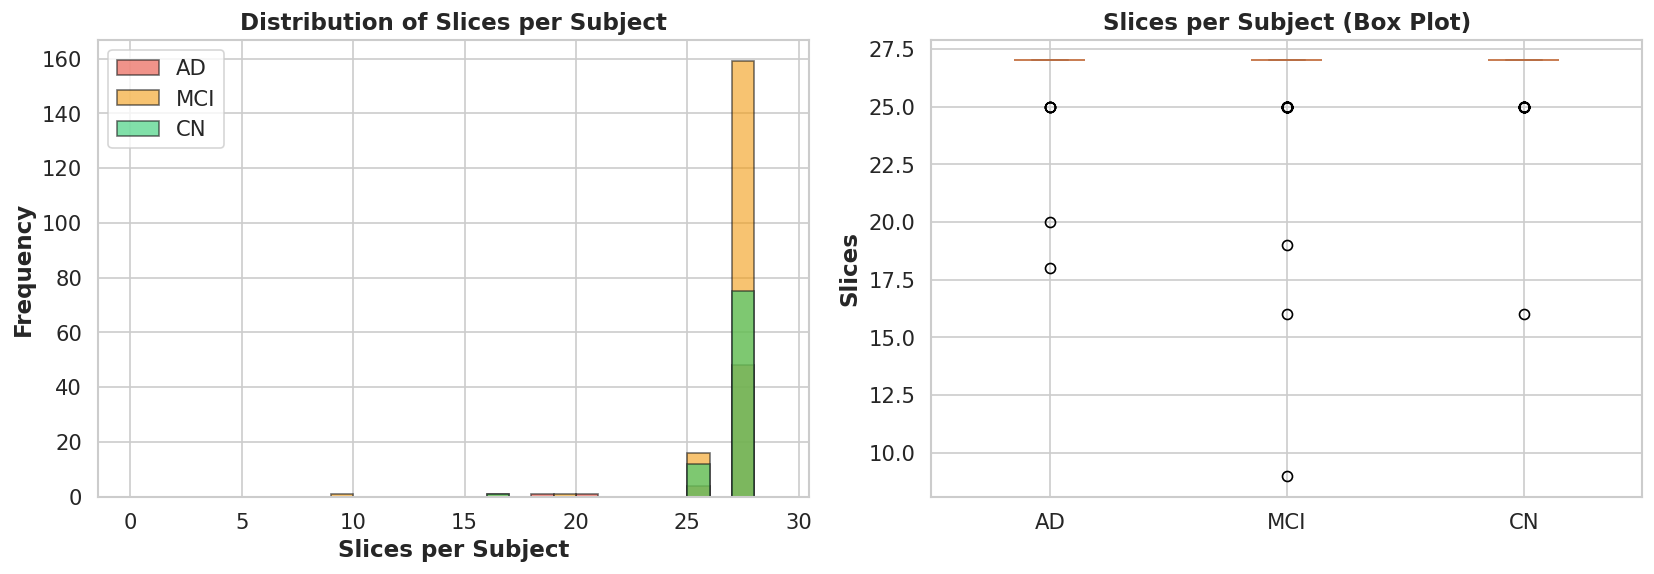


⚠️  5 subject(s) with < 20 slices:
   subject label  n_slices
127_S_6433    AD        18
027_S_1387   MCI        19
033_S_1309   MCI         9
128_S_1088   MCI        16
094_S_1241    CN        16


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for cls in CLASSES:
    sub = df[df["label"]==cls]["n_slices"]
    axes[0].hist(sub, bins=range(0, 30), alpha=0.6, label=cls, color=CLASS_COLORS[cls], edgecolor="k")
axes[0].set_xlabel("Slices per Subject")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Slices per Subject")
axes[0].legend()

# Box-plot
box_data = [df[df["label"]==c]["n_slices"].values for c in CLASSES]
bp = axes[1].boxplot(box_data, labels=CLASSES, patch_artist=True)
for patch, color in zip(bp["boxes"], [CLASS_COLORS[c] for c in CLASSES]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Slices")
axes[1].set_title("Slices per Subject (Box Plot)")

plt.tight_layout()
plt.show()

# Outliers
outliers = df[df["n_slices"] < 20]
if len(outliers):
    print(f"\n⚠️  {len(outliers)} subject(s) with < 20 slices:")
    print(outliers[["subject","label","n_slices"]].to_string(index=False))

<a id='6'></a>
## 6 · Image Properties & Sanity Checks

In [9]:
sample_paths = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    for subj in sorted(os.listdir(cls_dir))[:5]:
        sp = os.path.join(cls_dir, subj)
        if os.path.isdir(sp):
            pngs = sorted(glob.glob(os.path.join(sp, "*.png")))
            sample_paths.extend(pngs[:2])

widths, heights, modes, dtypes = [], [], [], []
is_gray_as_rgb = []
for p in sample_paths:
    img = Image.open(p)
    widths.append(img.size[0])
    heights.append(img.size[1])
    modes.append(img.mode)
    arr = np.array(img)
    dtypes.append(str(arr.dtype))
    if arr.ndim == 3 and arr.shape[2] == 3:
        is_gray_as_rgb.append(np.array_equal(arr[:,:,0], arr[:,:,1]) and
                               np.array_equal(arr[:,:,1], arr[:,:,2]))

print(f"Images sampled     : {len(sample_paths)}")
print(f"Widths             : {set(widths)}")
print(f"Heights            : {set(heights)}")
print(f"Modes              : {set(modes)}")
print(f"Dtypes             : {set(dtypes)}")
print(f"Grayscale-as-RGB   : {sum(is_gray_as_rgb)}/{len(is_gray_as_rgb)} "
      f"({'✅ All identical channels' if all(is_gray_as_rgb) else '⚠️ Some have colour info'})")

Images sampled     : 30
Widths             : {224}
Heights            : {224}
Modes              : {'RGB'}
Dtypes             : {'uint8'}
Grayscale-as-RGB   : 30/30 (✅ All identical channels)


<a id='7'></a>
## 7 · Sample Visualisation per Class

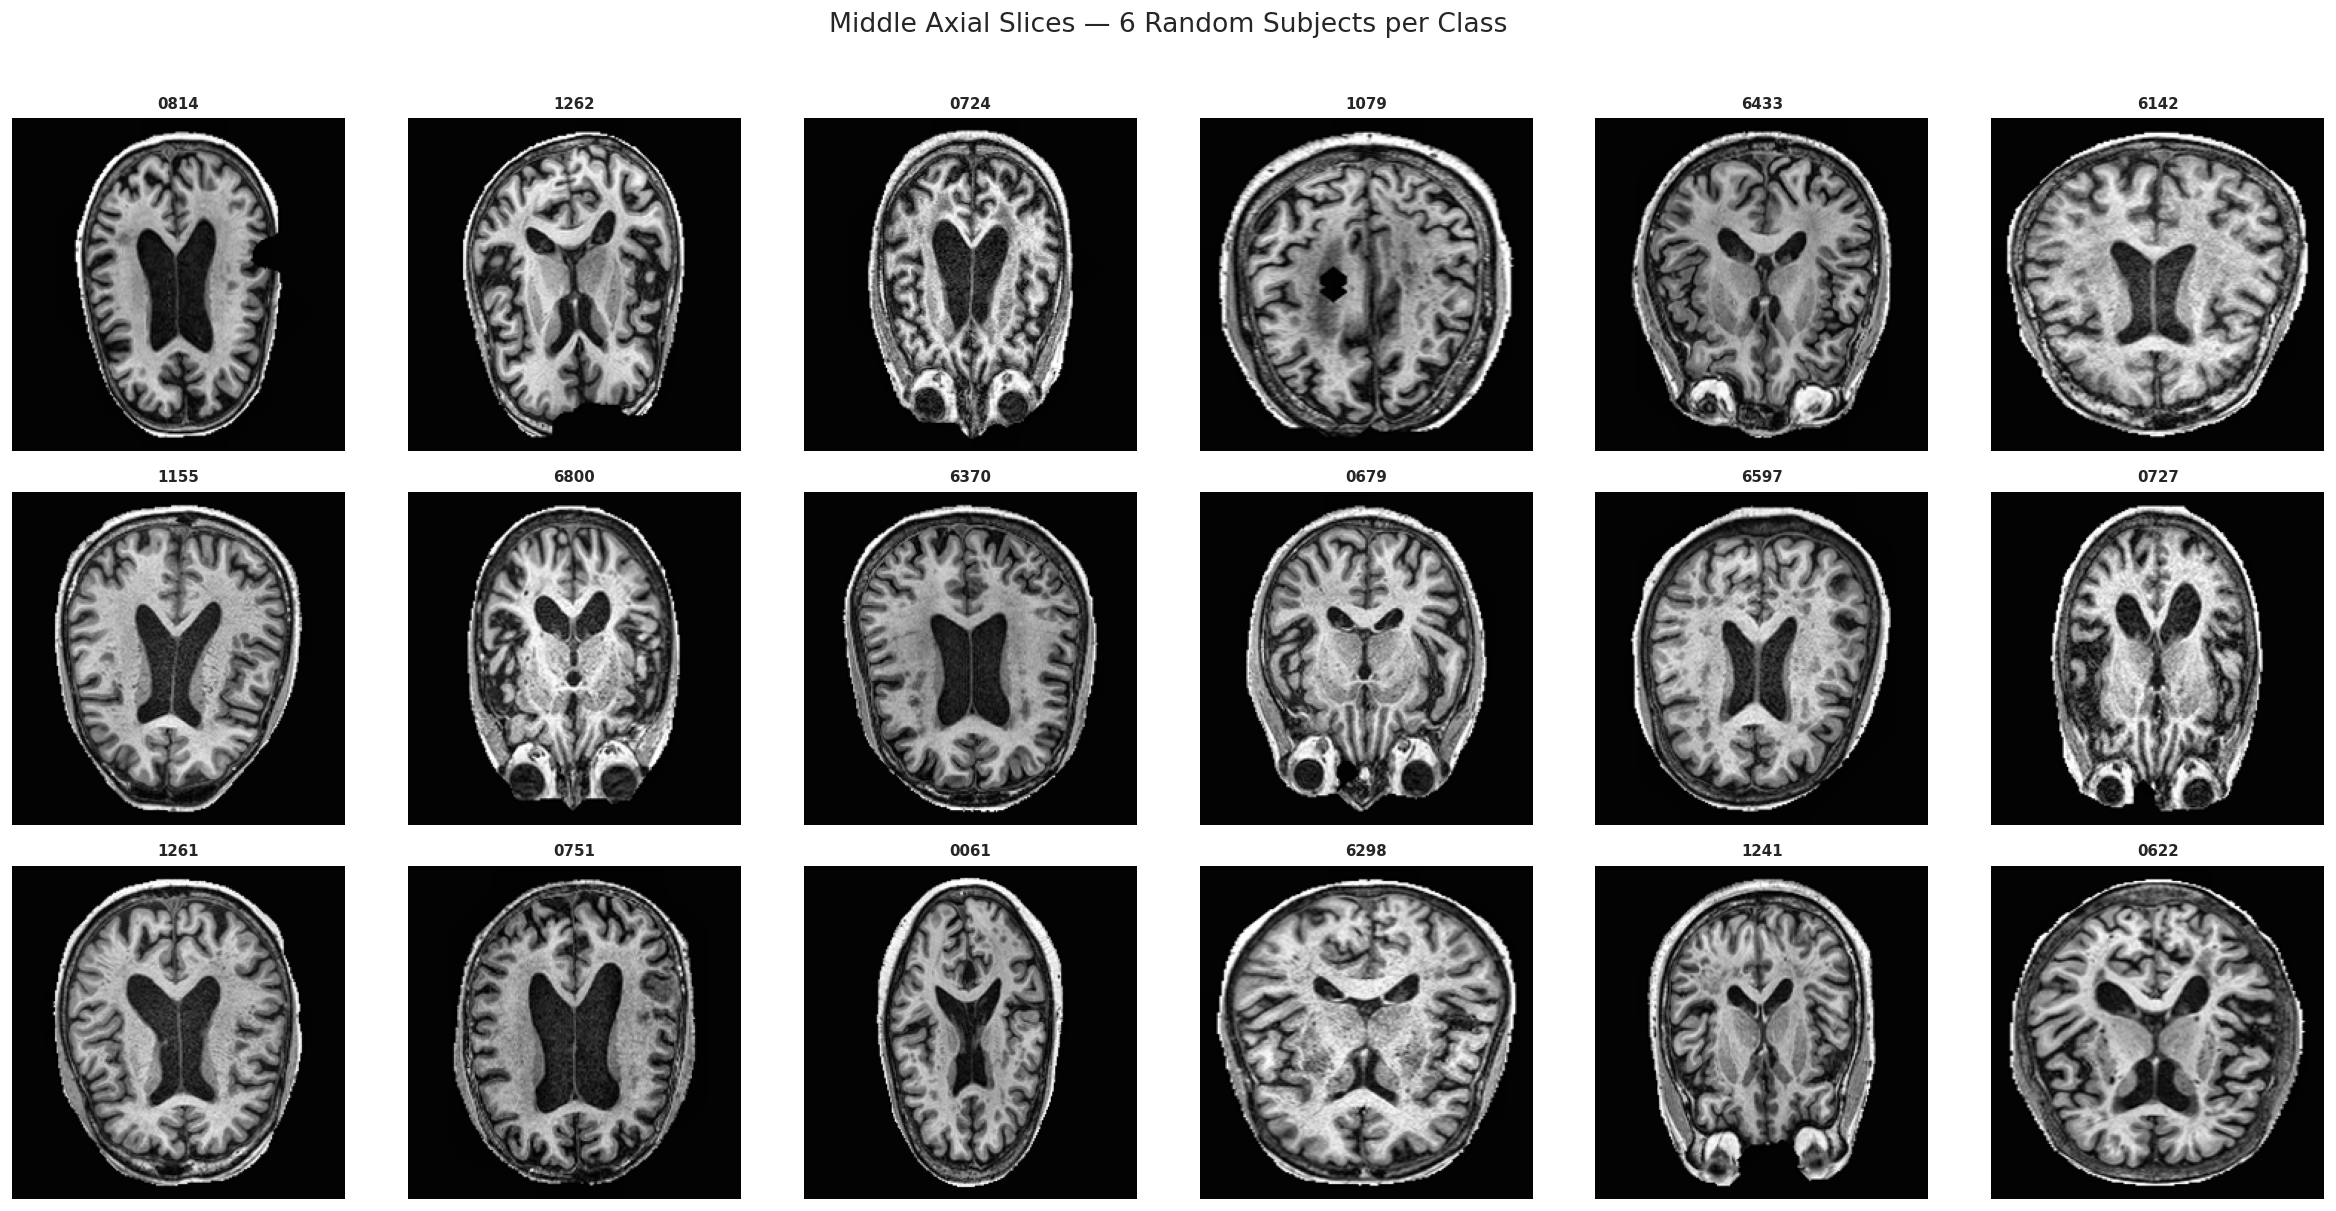

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_ROOT, cls)
    subjects = sorted(os.listdir(cls_dir))
    chosen = subjects[::len(subjects)//6][:6]  # spread across subjects
    for col, subj in enumerate(chosen):
        sp = os.path.join(cls_dir, subj)
        pngs = sorted(glob.glob(os.path.join(sp, "*.png")))
        mid = pngs[len(pngs)//2]  # middle slice
        img = np.array(Image.open(mid))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(subj.split("_S_")[1], fontsize=9)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cls, fontsize=14, fontweight="bold", rotation=0,
                             labelpad=50, va="center",
                             color=CLASS_COLORS[cls])

plt.suptitle("Middle Axial Slices — 6 Random Subjects per Class", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8 · Pixel Intensity Analysis

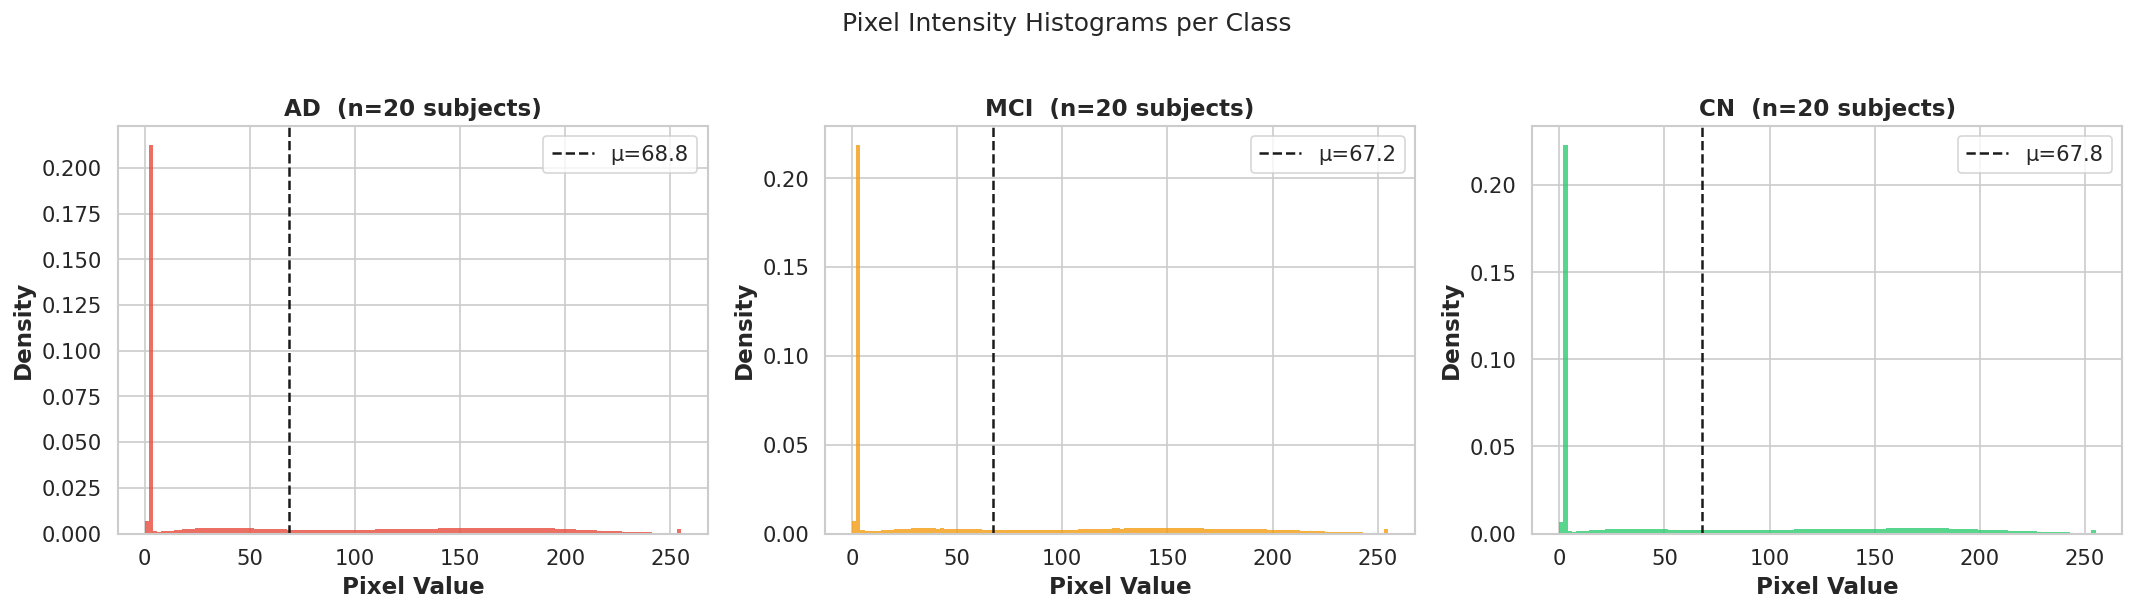

In [11]:
np.random.seed(42)
intensity_data = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    subjects = sorted(os.listdir(cls_dir))
    sampled = np.random.choice(subjects, size=min(20, len(subjects)), replace=False)
    for subj in sampled:
        sp = os.path.join(cls_dir, subj)
        pngs = sorted(glob.glob(os.path.join(sp, "*.png")))
        mid = pngs[len(pngs)//2]
        img = np.array(Image.open(mid).convert("L")).astype(np.float32)
        intensity_data[cls].append(img)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cls in zip(axes, CLASSES):
    all_px = np.concatenate([im.ravel() for im in intensity_data[cls]])
    ax.hist(all_px, bins=128, color=CLASS_COLORS[cls], alpha=0.8, density=True, edgecolor="none")
    ax.axvline(all_px.mean(), color="k", ls="--", lw=1.5, label=f"μ={all_px.mean():.1f}")
    ax.set_title(f"{cls}  (n={len(intensity_data[cls])} subjects)")
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Pixel Intensity Histograms per Class", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

<a id='9'></a>
## 9 · Per-Class Intensity Distributions (Overlaid)

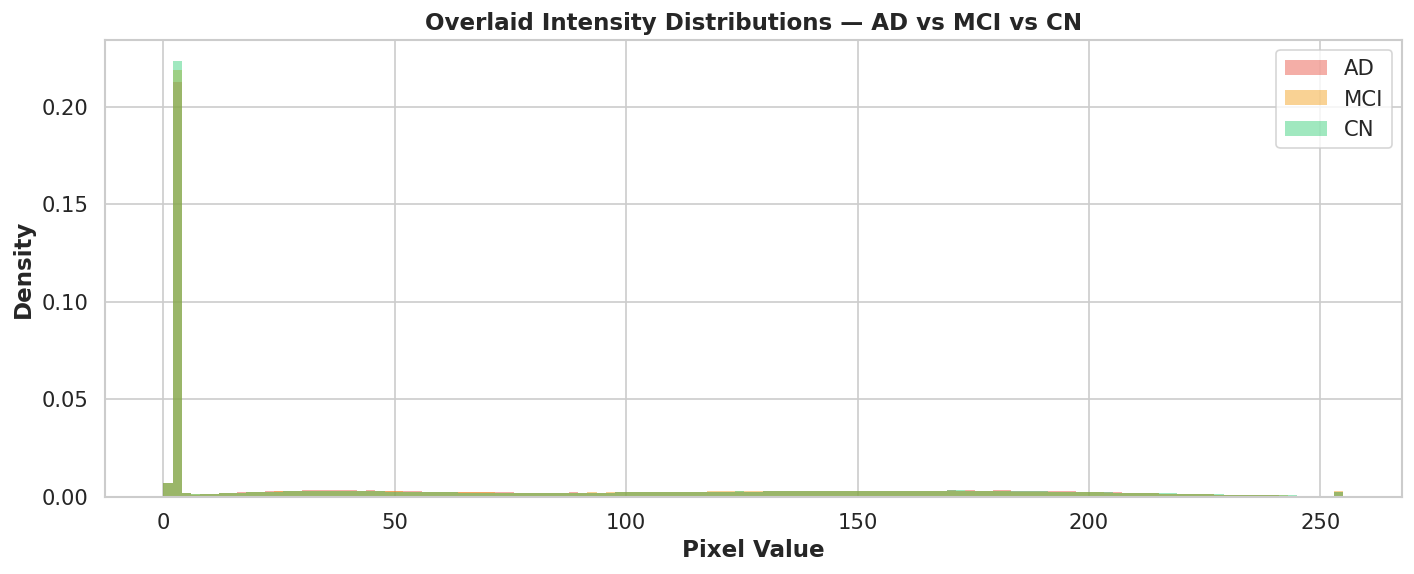

,Class,Mean,Std,Median,Skew,% Black (=0)
0,AD,68.79,76.22,32.00,0.732,1.2%
1,MCI,67.15,75.57,29.00,0.764,1.3%
2,CN,67.78,76.78,26.00,0.752,1.2%


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for cls in CLASSES:
    all_px = np.concatenate([im.ravel() for im in intensity_data[cls]])
    ax.hist(all_px, bins=128, alpha=0.45, density=True, label=cls,
            color=CLASS_COLORS[cls], edgecolor="none")
ax.set_xlabel("Pixel Value")
ax.set_ylabel("Density")
ax.set_title("Overlaid Intensity Distributions — AD vs MCI vs CN")
ax.legend()
plt.tight_layout()
plt.show()

# Stats table
rows_stat = []
for cls in CLASSES:
    all_px = np.concatenate([im.ravel() for im in intensity_data[cls]])
    rows_stat.append({
        "Class": cls,
        "Mean": f"{all_px.mean():.2f}",
        "Std": f"{all_px.std():.2f}",
        "Median": f"{np.median(all_px):.2f}",
        "Skew": f"{float(pd.Series(all_px).skew()):.3f}",
        "% Black (=0)": f"{(all_px==0).mean()*100:.1f}%",
    })
display(pd.DataFrame(rows_stat))

<a id='10'></a>
## 10 · Spatial Mean & Standard-Deviation Maps

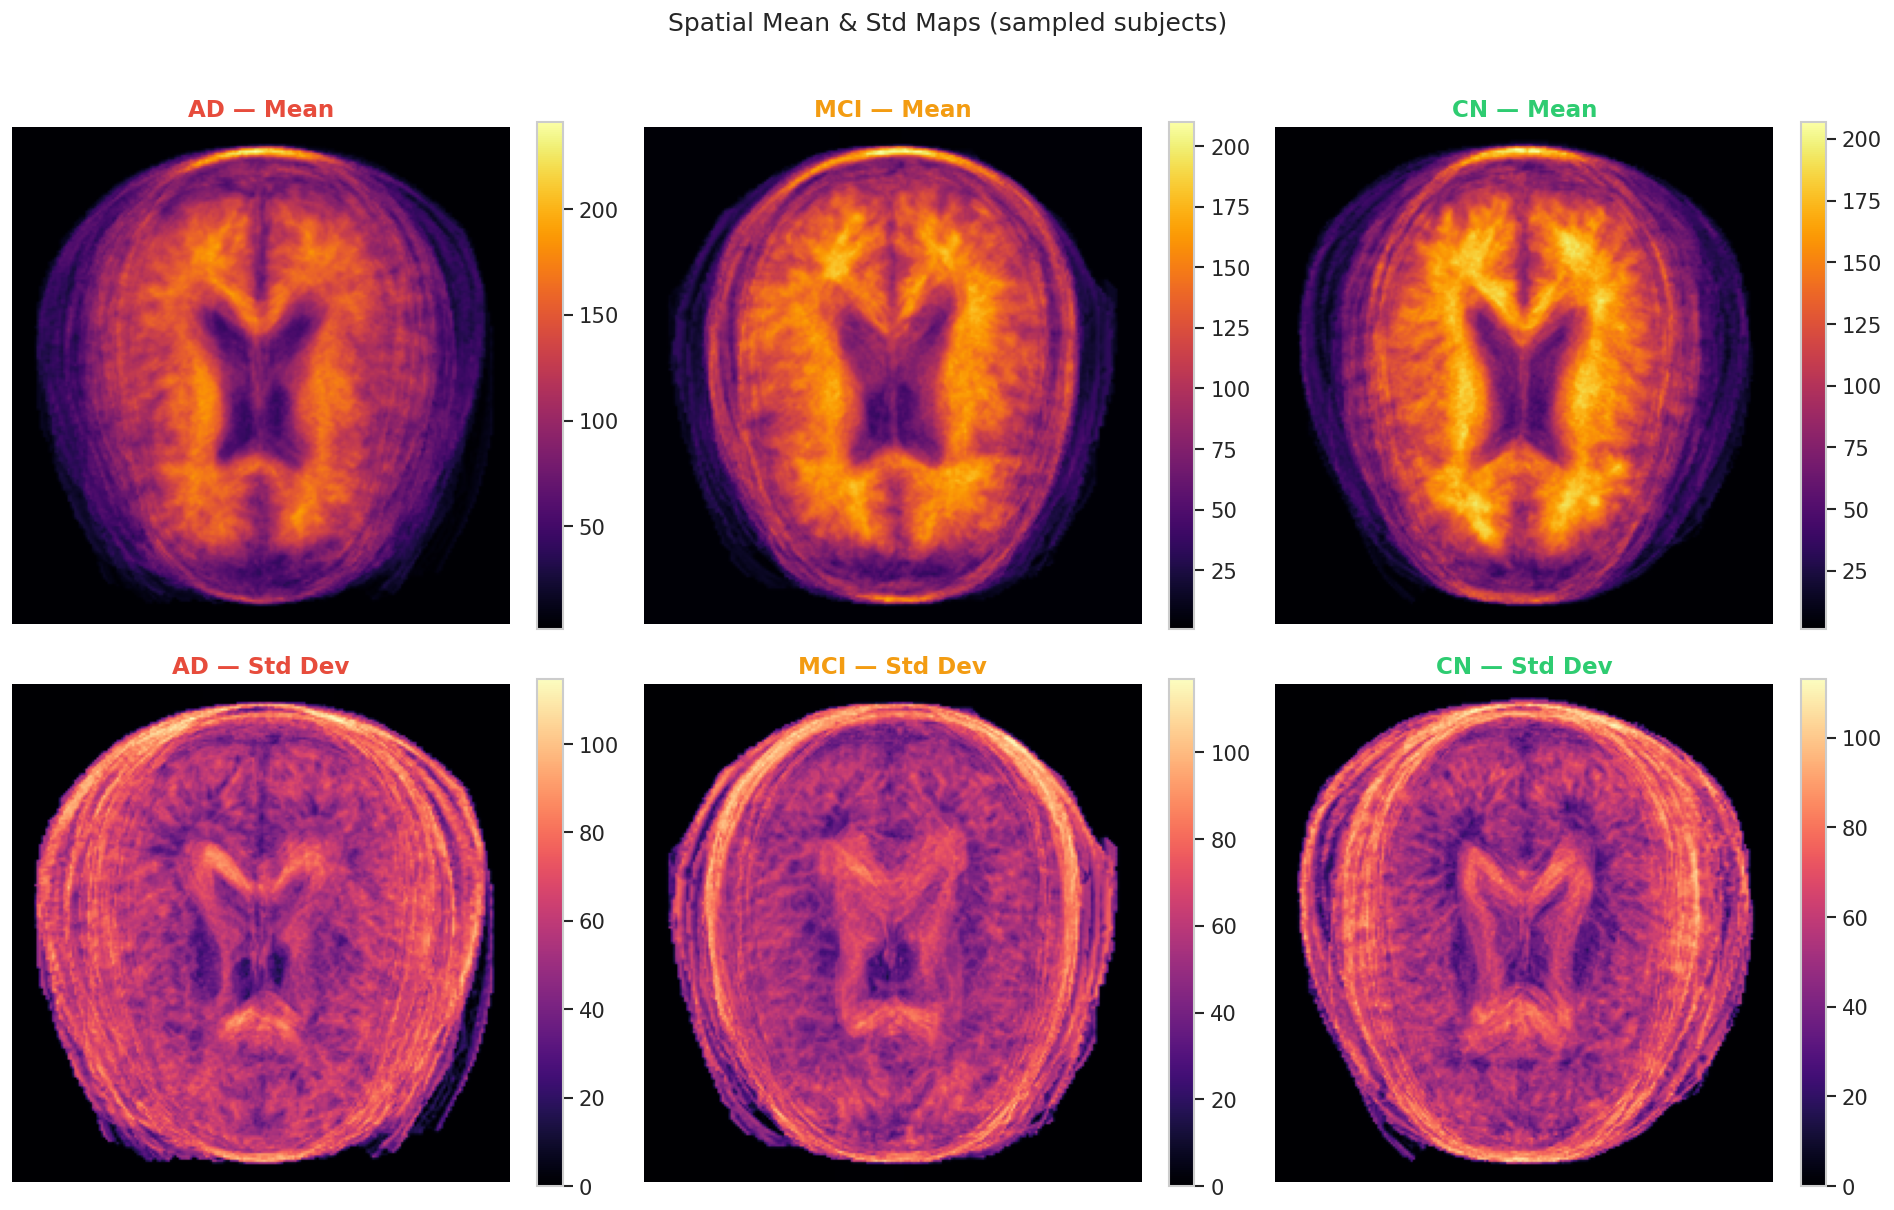

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for col, cls in enumerate(CLASSES):
    stack = np.stack([im for im in intensity_data[cls]], axis=0)
    mean_map = stack.mean(axis=0)
    std_map  = stack.std(axis=0)

    im1 = axes[0, col].imshow(mean_map, cmap="inferno")
    axes[0, col].set_title(f"{cls} — Mean", color=CLASS_COLORS[cls])
    axes[0, col].axis("off")
    plt.colorbar(im1, ax=axes[0, col], fraction=0.046)

    im2 = axes[1, col].imshow(std_map, cmap="magma")
    axes[1, col].set_title(f"{cls} — Std Dev", color=CLASS_COLORS[cls])
    axes[1, col].axis("off")
    plt.colorbar(im2, ax=axes[1, col], fraction=0.046)

plt.suptitle("Spatial Mean & Std Maps (sampled subjects)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

<a id='11'></a>
## 11 · Edge & Texture Analysis (Sobel Magnitude)

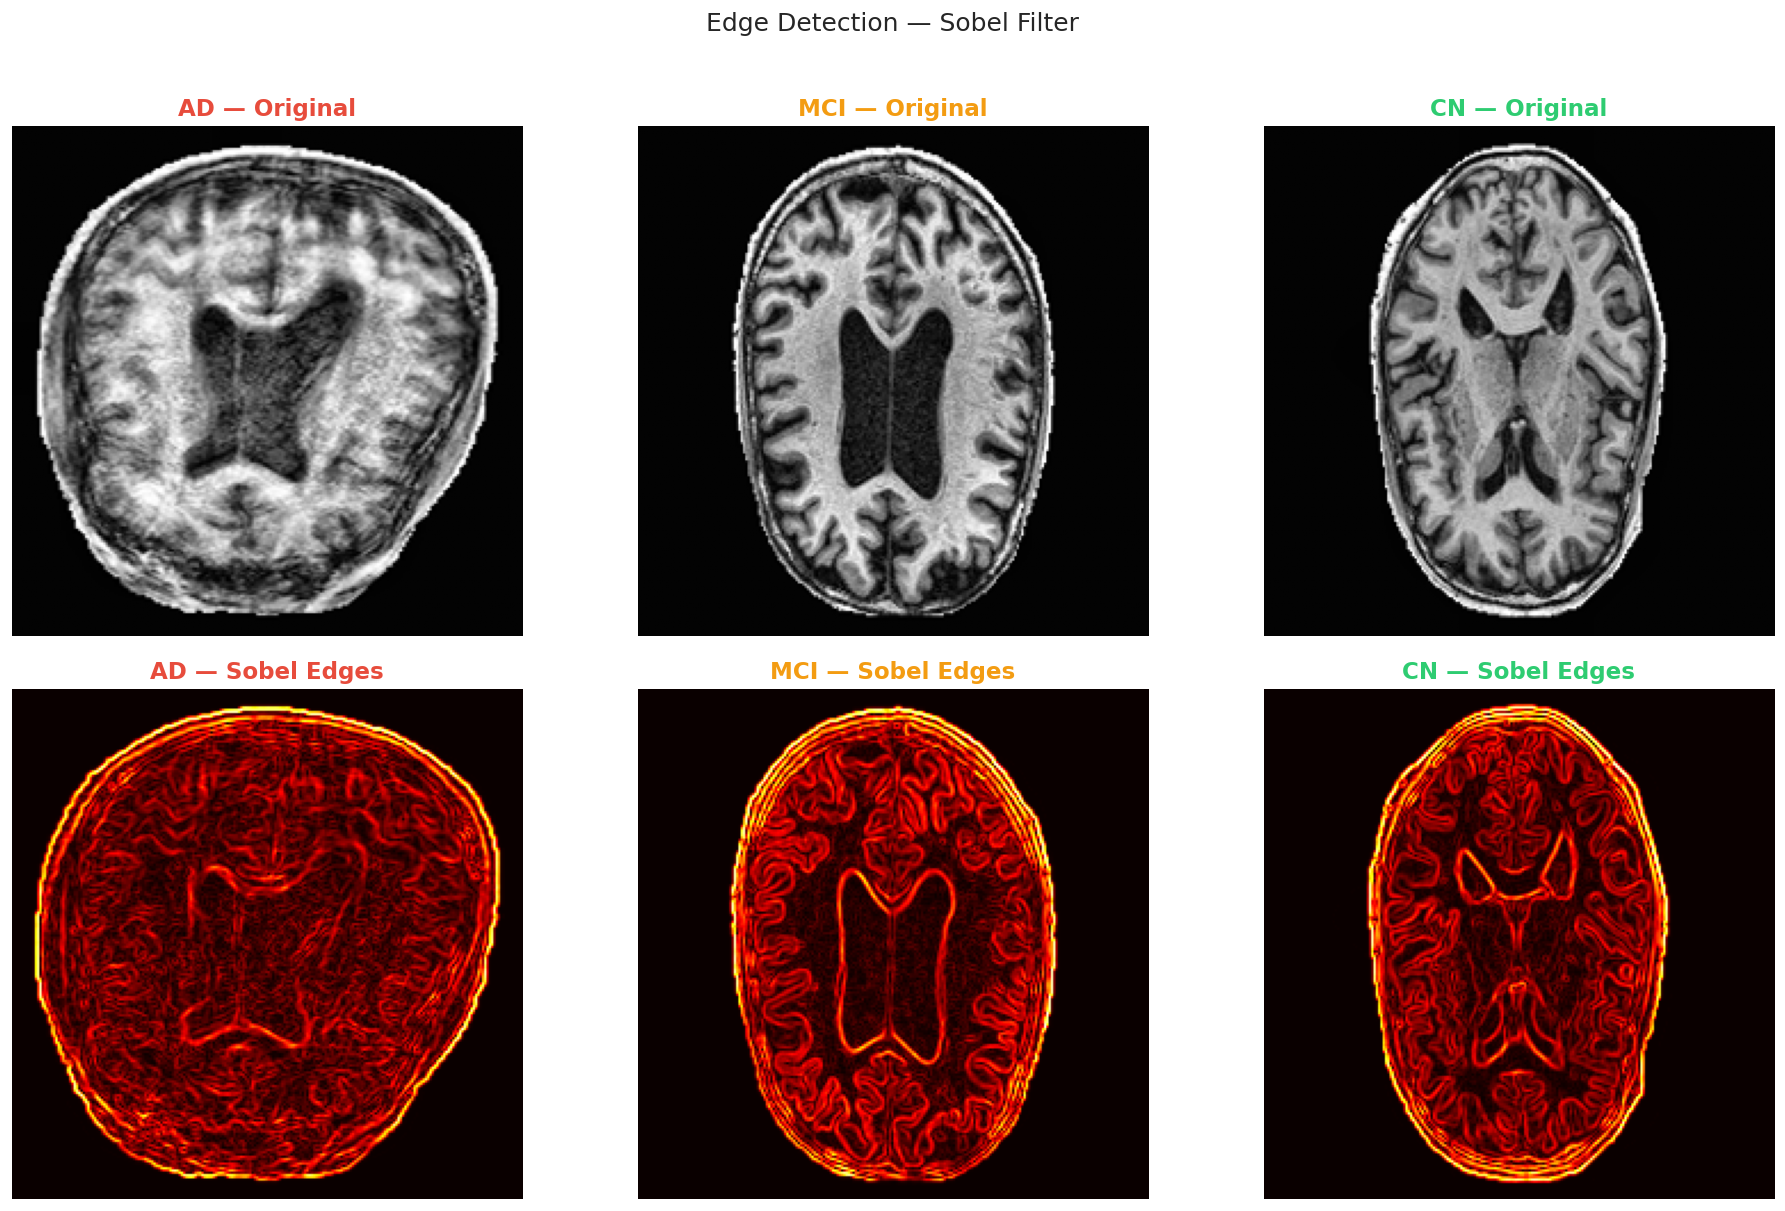

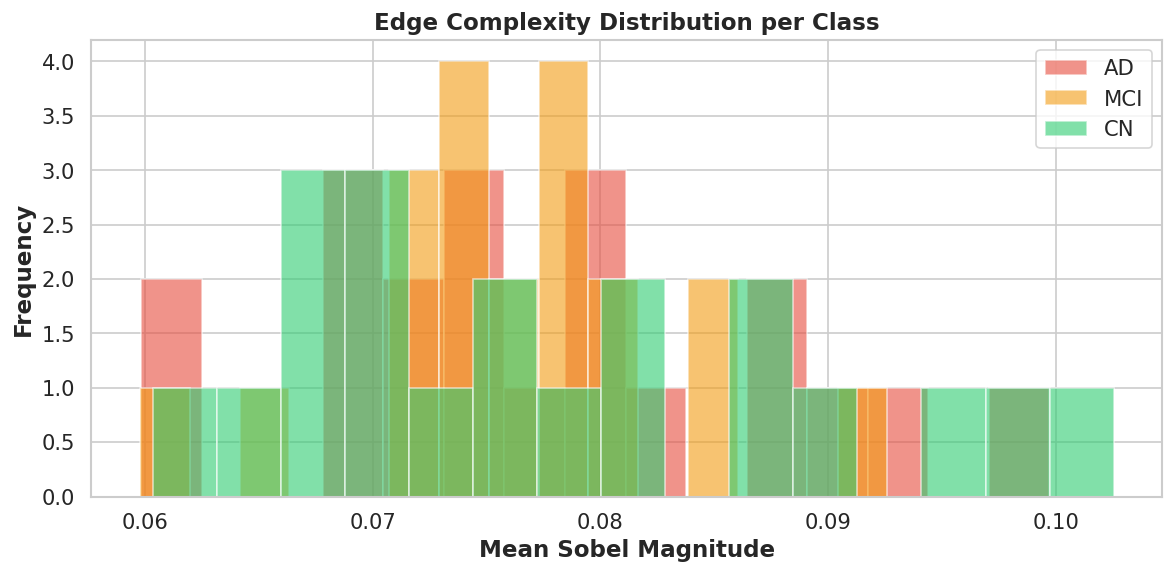

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
edge_means = {cls: [] for cls in CLASSES}

for col, cls in enumerate(CLASSES):
    sample_img = intensity_data[cls][0]
    sobel = filters.sobel(sample_img / 255.0)
    axes[0, col].imshow(sample_img, cmap="gray")
    axes[0, col].set_title(f"{cls} — Original", color=CLASS_COLORS[cls])
    axes[0, col].axis("off")
    axes[1, col].imshow(sobel, cmap="hot")
    axes[1, col].set_title(f"{cls} — Sobel Edges", color=CLASS_COLORS[cls])
    axes[1, col].axis("off")

    # Compute mean edge magnitude for all sampled
    for im in intensity_data[cls]:
        s = filters.sobel(im / 255.0)
        edge_means[cls].append(s.mean())

plt.suptitle("Edge Detection — Sobel Filter", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Edge magnitude comparison
fig, ax = plt.subplots(figsize=(10, 5))
for cls in CLASSES:
    ax.hist(edge_means[cls], bins=15, alpha=0.6, label=cls, color=CLASS_COLORS[cls])
ax.set_xlabel("Mean Sobel Magnitude")
ax.set_ylabel("Frequency")
ax.set_title("Edge Complexity Distribution per Class")
ax.legend()
plt.tight_layout()
plt.show()

<a id='12'></a>
## 12 · Intra-Class Image Similarity (SSIM)

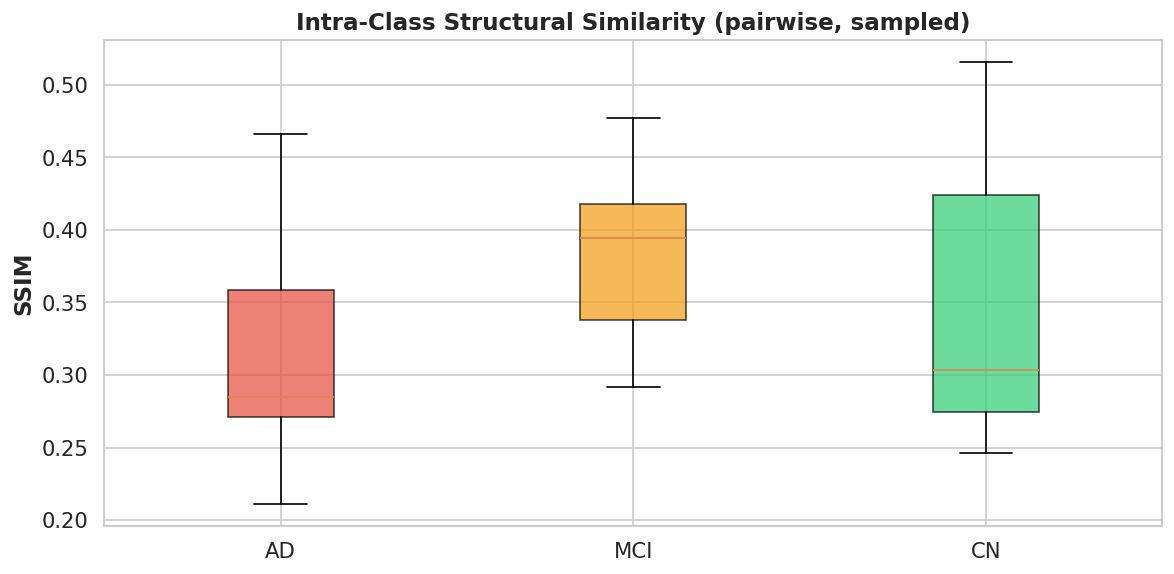

AD: mean SSIM = 0.3077, std = 0.0574
MCI: mean SSIM = 0.3835, std = 0.0492
CN: mean SSIM = 0.3550, std = 0.0862


In [15]:
ssim_scores = {cls: [] for cls in CLASSES}
for cls in CLASSES:
    imgs = intensity_data[cls][:10]
    for i in range(len(imgs)):
        for j in range(i+1, len(imgs)):
            s = ssim(imgs[i], imgs[j], data_range=255)
            ssim_scores[cls].append(s)

fig, ax = plt.subplots(figsize=(10, 5))
bp_data = [ssim_scores[c] for c in CLASSES]
bp = ax.boxplot(bp_data, labels=CLASSES, patch_artist=True)
for patch, cls in zip(bp["boxes"], CLASSES):
    patch.set_facecolor(CLASS_COLORS[cls])
    patch.set_alpha(0.7)
ax.set_ylabel("SSIM")
ax.set_title("Intra-Class Structural Similarity (pairwise, sampled)")
plt.tight_layout()
plt.show()

for cls in CLASSES:
    arr = ssim_scores[cls]
    print(f"{cls}: mean SSIM = {np.mean(arr):.4f}, std = {np.std(arr):.4f}")

<a id='13'></a>
## 13 · Duplicate / Near-Duplicate Detection

In [16]:
print("Computing perceptual hashes (downscaled 8×8 DCT) …")
from collections import defaultdict

def phash(img_path, size=8):
    img = Image.open(img_path).convert("L").resize((size*4, size*4), Image.LANCZOS)
    arr = np.array(img, dtype=np.float64)
    dct = np.fft.fft2(arr)[:size, :size]
    med = np.median(np.abs(dct))
    return hashlib.md5(np.packbits(np.abs(dct) > med).tobytes()).hexdigest()

hash_map = defaultdict(list)
total = 0
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    for subj in sorted(os.listdir(cls_dir)):
        sp = os.path.join(cls_dir, subj)
        if not os.path.isdir(sp): continue
        for f in sorted(glob.glob(os.path.join(sp, "*.png"))):
            h = phash(f)
            hash_map[h].append(f)
            total += 1

dups = {k: v for k, v in hash_map.items() if len(v) > 1}
dup_images = sum(len(v) for v in dups.values()) - len(dups)
print(f"Total images hashed : {total:,}")
print(f"Unique hashes       : {len(hash_map):,}")
print(f"Duplicate groups    : {len(dups)}")
print(f"Duplicate images    : {dup_images}")

if dups:
    print("\nSample duplicate groups (first 5):")
    for i, (h, paths) in enumerate(list(dups.items())[:5]):
        short = ["/".join(p.split("/")[-3:]) for p in paths]
        print(f"  Group {i+1}: {short}")

Computing perceptual hashes (downscaled 8×8 DCT) …
Total images hashed : 8,512
Unique hashes       : 8,395
Duplicate groups    : 115
Duplicate images    : 117

Sample duplicate groups (first 5):
  Group 1: ['AD/005_S_0814/005_S_0814_z127.png', 'AD/005_S_0814/005_S_0814_z128.png']
  Group 2: ['AD/011_S_6303/011_S_6303_z116.png', 'AD/011_S_6303/011_S_6303_z117.png']
  Group 3: ['AD/023_S_0139/023_S_0139_z101.png', 'AD/023_S_0139/023_S_0139_z102.png']
  Group 4: ['AD/023_S_0916/023_S_0916_z134.png', 'AD/023_S_0916/023_S_0916_z135.png']
  Group 5: ['AD/023_S_6661/023_S_6661_z114.png', 'AD/023_S_6661/023_S_6661_z115.png']
